In [23]:
from gurobipy import Model, GRB
import matplotlib.pyplot as plt


# Input data
n = 4 # number of jobs
m = 3 # number of machines
times = [[4,2,1], [3,1,2], [2,4,2],[2,3,2]] # processing times of jobs on machines

# Adding Paths
D = [[0,2,4],[2,0,3],[4,3,0]]



# Calculate a large constant 'M' that will be used in the model. This is the summation of all processing times.
M = sum(times[i][j] for i in range(n) for j in range(m)) + (m-1) * max(max(row) for row in D)
machines = [[0, 1, 2], [2, 1, 0], [0, 2, 1],[1,0,2]] # ordering of jobs on machines


# Initialize the optimization model
model = Model("jssp")

# Create variables
x = {}  # Starting times for jobs on machines
y = {}  # Binary variables to help model non-overlapping constraints

# Define decision variables
for i in range(m):
    for j in range(n):
        # Continuous variable representing the starting time of job 'j' on machine 'i'
        x[i, j] = model.addVar(vtype=GRB.CONTINUOUS, name=f"x_{i}_{j}")
        
        for k in range(n):
            if j != k:
                # Binary variable that is 1 if job 'j' precedes job 'k' on machine 'i', and 0 otherwise
                y[i, j, k] = model.addVar(vtype=GRB.BINARY, name=f"y_{i}_{j}_{k}")

# Variable representing the makespan (maximum completion time across all jobs)
C = model.addVar(vtype=GRB.CONTINUOUS, name="C")

# Objective function: Minimize the makespan (adapted to also start jobs as soon as possible)
model.setObjective(C + 0.0001*sum(x[i, j] for i in range(m) for j in range(n)), GRB.MINIMIZE)

# Add constraints
for j in range(n):
    for r in range(1, m):
        # Precedence constraints: Ensure that a job on a machine only starts after 
        # the processing of the previous machine is concluded
        prev_m = machines[j][r-1]
        next_m = machines[j][r]
        model.addConstr(
            x[next_m, j] >= x[prev_m, j] + times[j][prev_m] + D[prev_m][next_m]
        )

       
for j in range(n):
    machine = machines[j][m-1]
    model.addConstr(C >= x[machine, j] + times[j][machine])
        
for i in range(m):
    for j in range(n):
        for k in range(n):
            if j != k:
                # Disjunctive constraints: Ensure that two jobs do not overlap on the same machine.
                # These constraints use the big 'M' methodology in combination with binary variables.
                model.addConstr(x[i, j] >= x[i, k] + times[k][i] - M * (1 - y[i, j, k]))
                model.addConstr(x[i, k] >= x[i, j] + times[j][i] - M * y[i, j, k])

# Optimize the model to find the optimal solution
model.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7600X 6-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de
Optimize a model with 84 rows, 49 columns and 240 nonzeros
Model fingerprint: 0x093c5d06
Variable types: 13 continuous, 36 integer (36 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+01]
  Objective range  [1e-04, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+01]
Found heuristic solution: objective 23.0104000
Presolve removed 4 rows and 4 columns
Presolve time: 0.00s
Presolved: 80 rows, 45 columns, 224 nonzeros
Variable types: 13 continuous, 32 integer (32 binary)

Root relaxation: objective 1.500630e+01, 17 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds 

In [24]:
# Print Solution
print("\nSolution:\n")
for i in range(m):
    # Sort jobs for each machine based on start times
    scheduled_jobs = sorted([(int(x[i, j].X), j) for j in range(n)])
    
    print(f"Machine {i}:")
    for start_time, job in scheduled_jobs:
        print(f"  Job {job} from time {start_time} to {start_time + times[job][i]}")
    print()


Solution:

Machine 0:
  Job 2 from time 0 to 2
  Job 0 from time 2 to 6
  Job 3 from time 6 to 8
  Job 1 from time 8 to 11

Machine 1:
  Job 3 from time 0 to 3
  Job 1 from time 5 to 6
  Job 0 from time 8 to 10
  Job 2 from time 11 to 15

Machine 2:
  Job 1 from time 0 to 2
  Job 2 from time 6 to 8
  Job 3 from time 12 to 14
  Job 0 from time 14 to 15



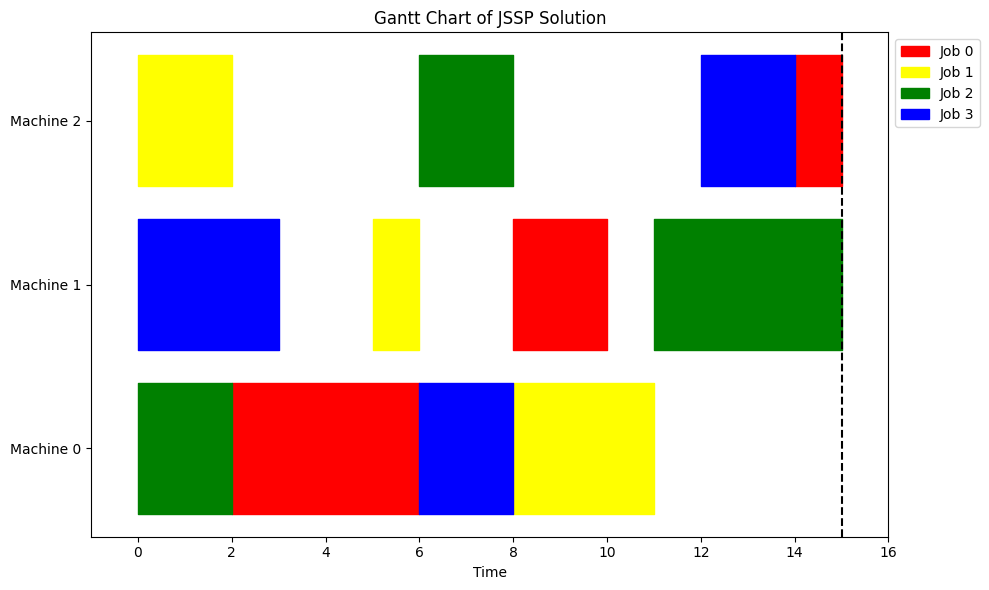

In [25]:
# Check if the optimization was successful
if model.Status == GRB.OPTIMAL:
    # Visualize the optimal schedule using a Gantt chart
    if n <= 4:
        job_colors = ['red','yellow','green', 'blue']
    else:
        import matplotlib.cm as cm
        job_colors = [cm.viridis(i/n) for i in range(n)]
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    ax.set_xlim(-1,C.x+1)
    for j in range(n):
        for r in range(m):
            machine = r
            # Plot each job's duration on its respective machine
            ax.broken_barh([(model.getVarByName(f"x_{machine}_{j}").x, times[j][r])], (machine - 0.4, 0.8), color=job_colors[j], label=f"Job {j}")

    ax.set_yticks(list(range(m)))
    ax.set_yticklabels([f"Machine {i}" for i in range(m)])
    ax.set_xlabel("Time")
    ax.set_title("Gantt Chart of JSSP Solution")
    
    # Add a vertical line at max time
    ax.axvline(x=C.x, color='black', linestyle='--', label='C_max')
    
    # Add a legend to the chart for clarity
    handles = [plt.Rectangle((0,0),1,1, color=job_colors[j]) for j in range(n)]
    
    ax.legend(handles, [f"Job {j}" for j in range(n)], loc="upper left", bbox_to_anchor=(1, 1))
    


    plt.tight_layout()
    plt.show()
else:
    print("No optimal solution found!")

In [ ]:
from gurobipy import Model, GRB
import matplotlib.pyplot as plt


# Input data
n = 4 # number of jobs
m = 3 # number of machines
times = [[4,2,1], [3,1,2], [2,4,2],[2,3,2]] # processing times of jobs on machines

# Adding Paths
D = [[0,2,4],[2,0,3],[4,3,0]]



# Calculate a large constant 'M' that will be used in the model. This is the summation of all processing times.
M = sum(times[i][j] for i in range(n) for j in range(m)) + (m-1) * max(max(row) for row in D)
machines = [[0, 1, 2], [2, 1, 0], [0, 2, 1],[1,0,2]] # ordering of jobs on machines

# Precedence Graph
PrecRelations = [[(1, 2)], [(1, 0)], [(0, 2)], [(0,2)]]


# Initialize the optimization model
model = Model("jssp")

# Create variables
x = {}  # Starting times for jobs on machines
y = {}  # Binary variables to help model non-overlapping constraints
y2 = {}  # Binary variables to help model non-overlapping constraints

# Define decision variables
for i in range(m):
    for j in range(n):
        # Continuous variable representing the starting time of job 'j' on machine 'i'
        x[i, j] = model.addVar(vtype=GRB.CONTINUOUS, name=f"x_{i}_{j}")
        
        for k in range(n):
            if j != k:
                # Binary variable that is 1 if job 'j' precedes job 'k' on machine 'i', and 0 otherwise
                y[i, j, k] = model.addVar(vtype=GRB.BINARY, name=f"y_{i}_{j}_{k}")

for j in range(n):
    for i in range(m):
        for k in range(m):
                if i != k:
                    y2[j, i, k] = model.addVar(vtype=GRB.BINARY, name=f"y_{j}_{i}_{k}")

# Variable representing the makespan (maximum completion time across all jobs)
C = model.addVar(vtype=GRB.CONTINUOUS, name="C")

# Objective function: Minimize the makespan (adapted to also start jobs as soon as possible)
model.setObjective(C + 0.0001*sum(x[i, j] for i in range(m) for j in range(n)), GRB.MINIMIZE)

# Add constraints
for j in range(n):
    for (s, sp) in PrecRelations[j]:  # edges s -> sp
        model.addConstr(x[sp, j] >= x[s, j] + times[j][s] + D[s][sp])

      
for j in range(n):
    for i in range(m):
        model.addConstr(C >= x[i, j] + times[j][i])
        
for i in range(m):
    for j in range(n):
        for k in range(n):
            if j != k:
                # Disjunctive constraints: Ensure that two jobs do not overlap on the same machine.
                # These constraints use the big 'M' methodology in combination with binary variables.
                model.addConstr(x[i, j] >= x[i, k] + times[k][i] - M * (1 - y[i, j, k]))
                model.addConstr(x[i, k] >= x[i, j] + times[j][i] - M * y[i, j, k])

# Ensure one constraint is not on multiple machines at the same time
for j in range(n):
    for s in range(m):
        for s_ in range(m):
            edges_j = set(PrecRelations[j])
            if (s, s_) not in edges_j and (s_, s) not in edges_j and s != s_:
                model.addConstr(x[s_, j] >= x[s, j] + times[j][s] + D[s][s_] - M * (1 - y2[j, s, s_]))
                model.addConstr(x[s, j] >= x[s_, j] + times[j][s_] + D[s_][s] - M * y2[j, s, s_])                

# Optimize the model to find the optimal solution
model.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7600X 6-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de
Optimize a model with 120 rows, 73 columns and 344 nonzeros
Model fingerprint: 0xea1ddf86
Variable types: 13 continuous, 60 integer (60 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+01]
  Objective range  [1e-04, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 4e+01]
Found heuristic solution: objective 19.0083000
Presolve removed 0 rows and 8 columns
Presolve time: 0.00s
Presolved: 120 rows, 65 columns, 344 nonzeros
Variable types: 13 continuous, 52 integer (52 binary)

Root relaxation: objective 1.000200e+01, 22 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bound

In [27]:
# Print Solution
print("\nSolution:\n")
for i in range(m):
    # Sort jobs for each machine based on start times
    scheduled_jobs = sorted([(int(x[i, j].X), j) for j in range(n)])
    
    print(f"Machine {i}:")
    for start_time, job in scheduled_jobs:
        print(f"  Job {job} from time {start_time} to {start_time + times[job][i]}")
    print()


Solution:

Machine 0:
  Job 2 from time 0 to 2
  Job 3 from time 2 to 4
  Job 1 from time 8 to 11
  Job 0 from time 11 to 15

Machine 1:
  Job 0 from time 0 to 2
  Job 1 from time 5 to 6
  Job 3 from time 6 to 9
  Job 2 from time 11 to 15

Machine 2:
  Job 1 from time 0 to 2
  Job 0 from time 5 to 6
  Job 2 from time 6 to 8
  Job 3 from time 12 to 14



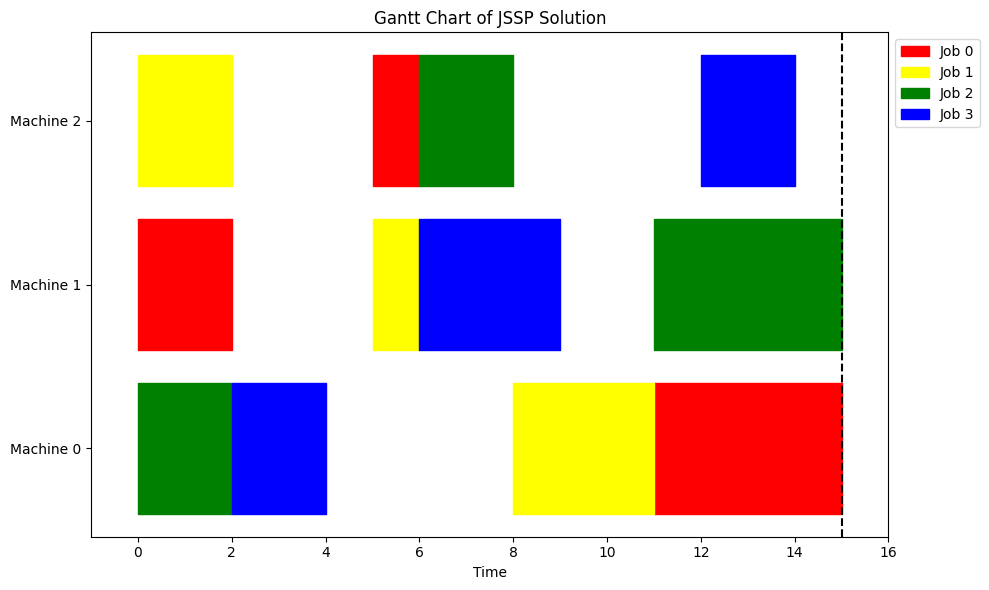

In [28]:
# Check if the optimization was successful
if model.Status == GRB.OPTIMAL:
    # Visualize the optimal schedule using a Gantt chart
    if n <= 4:
        job_colors = ['red','yellow','green', 'blue']
    else:
        import matplotlib.cm as cm
        job_colors = [cm.viridis(i/n) for i in range(n)]
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    ax.set_xlim(-1,C.x+1)
    for j in range(n):
        for r in range(m):
            machine = r
            # Plot each job's duration on its respective machine
            ax.broken_barh([(model.getVarByName(f"x_{machine}_{j}").x, times[j][r])], (machine - 0.4, 0.8), color=job_colors[j], label=f"Job {j}")

    ax.set_yticks(list(range(m)))
    ax.set_yticklabels([f"Machine {i}" for i in range(m)])
    ax.set_xlabel("Time")
    ax.set_title("Gantt Chart of JSSP Solution")
    
    # Add a vertical line at max time
    ax.axvline(x=C.x, color='black', linestyle='--', label='C_max')
    
    # Add a legend to the chart for clarity
    handles = [plt.Rectangle((0,0),1,1, color=job_colors[j]) for j in range(n)]
    
    ax.legend(handles, [f"Job {j}" for j in range(n)], loc="upper left", bbox_to_anchor=(1, 1))
    


    plt.tight_layout()
    plt.show()
else:
    print("No optimal solution found!")

In [29]:
from gurobipy import Model, GRB, quicksum

def solve_matrix_light_single_prec(
    V,                      # number of cars
    S,                      # number of stations/operations
    t,                      # processing times: t[s] or t[v][s]
    prec_edges,             # list of precedence edges: [(s, sp), ...] applies to ALL cars
    D=None,                 # distance matrix D[s][sp] (optional)
    add_car_capacity=True,  # include SV constraints
    add_station_capacity=True # include UV constraints
):
    """
    Matrix-production light model (single precedence graph for all cars):
    - ST[v,s] start time of car v at station s
    - Cmax makespan
    - UV[v,v',s] orders cars on a station (non-overlap)
    - SV[v,s,s'] orders stations for a car (non-overlap within car) for unordered pairs
    - precedence edges restrict allowed order (same for all cars)
    - optional travel times D
    """

    cars = range(V)
    stations = range(S)

    # If no travel times are given, use zeros
    if D is None:
        D = [[0 for _ in stations] for __ in stations]

    # Helper: processing time access (allow t[s] or t[v][s])
    def p(v, s):
        return t[v][s] if isinstance(t[0], (list, tuple)) else t[s]

    # Big-M: safe upper bound for time horizon
    maxD = max(max(row) for row in D) if D else 0
    M = sum(p(v, s) for v in cars for s in stations) + (S - 1) * maxD

    m = Model("matrix_production_light_single_prec")

    # -------------------------
    # Decision variables
    # -------------------------
    ST = m.addVars(cars, stations, vtype=GRB.CONTINUOUS, lb=0.0, name="ST")
    Cmax = m.addVar(vtype=GRB.CONTINUOUS, lb=0.0, name="Cmax")

    # UV for station-capacity: only define for v < v' to avoid duplicates
    if add_station_capacity:
        UV = m.addVars(
            [(v, vp, s) for s in stations for v in cars for vp in cars if v < vp],
            vtype=GRB.BINARY,
            name="UV"
        )
    else:
        UV = None

    # SV for car-capacity: define only for s < s' AND only if unordered wrt precedence (global)
    if add_car_capacity:
        edges = set(prec_edges)

        # unordered station pairs (s,sp) with s<sp and neither direction is in edges
        unordered_pairs = [
            (s, sp)
            for s in stations
            for sp in stations
            if s < sp and (s, sp) not in edges and (sp, s) not in edges
        ]

        SV = m.addVars(
            [(v, s, sp) for v in cars for (s, sp) in unordered_pairs],
            vtype=GRB.BINARY,
            name="SV"
        )
    else:
        SV = None
        unordered_pairs = []

    # -------------------------
    # Objective
    # -------------------------
    m.setObjective(Cmax, GRB.MINIMIZE)

    # -------------------------
    # Constraints
    # -------------------------

    # (1) Makespan bound: Cmax >= completion time of every car at every station
    m.addConstrs(
        (Cmax >= ST[v, s] + p(v, s) for v in cars for s in stations),
        name="makespan"
    )

    # (2) Precedence constraints: successor starts after predecessor finishes (+ travel time)
    for v in cars:
        for (s, sp) in prec_edges:
            m.addConstr(
                ST[v, sp] >= ST[v, s] + p(v, s) + D[s][sp],
                name=f"prec_v{v}_{s}_{sp}"
            )

    # (3) Station capacity (no overlap of two cars on same station)
    if add_station_capacity:
        for s in stations:
            for v in cars:
                for vp in cars:
                    if v < vp:
                        # UV[v,vp,s] = 1 => v before vp on station s
                        m.addConstr(
                            ST[vp, s] >= ST[v, s] + p(v, s) - M * (1 - UV[v, vp, s]),
                            name=f"station_nooverlap_1_s{s}_v{v}_vp{vp}"
                        )
                        m.addConstr(
                            ST[v, s] >= ST[vp, s] + p(vp, s) - M * UV[v, vp, s],
                            name=f"station_nooverlap_2_s{s}_v{v}_vp{vp}"
                        )

    # (4) Car capacity (a car cannot be on two stations at same time) for unordered pairs
    if add_car_capacity:
        for v in cars:
            for (s, sp) in unordered_pairs:
                # SV[v,s,sp] = 1 => s before sp for car v
                m.addConstr(
                    ST[v, sp] >= ST[v, s] + p(v, s) + D[s][sp] - M * (1 - SV[v, s, sp]),
                    name=f"car_nooverlap_1_v{v}_{s}_{sp}"
                )
                m.addConstr(
                    ST[v, s] >= ST[v, sp] + p(v, sp) + D[sp][s] - M * SV[v, s, sp],
                    name=f"car_nooverlap_2_v{v}_{s}_{sp}"
                )

    # Solve
    m.optimize()

    # Collect solution (if any)
    if m.status in (GRB.OPTIMAL, GRB.TIME_LIMIT):
        ST_sol = {(v, s): ST[v, s].X for v in cars for s in stations}
        return {
            "Cmax": Cmax.X,
            "ST": ST_sol,
            "status": m.status
        }
    else:
        return {"status": m.status}


In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_gantt_matrix_light(V, S, t, ST_sol, Cmax, title="Gantt Chart (Matrix-light)"):
    """
    V: number of cars
    S: number of stations
    t: processing times: either t[s] or t[v][s]
    ST_sol: dict {(v,s): start_time}
    Cmax: makespan
    """

    cars = range(V)
    stations = range(S)

    # processing time accessor
    def p(v, s):
        return t[v][s] if isinstance(t[0], (list, tuple)) else t[s]

    # Colors
    if V <= 10:
        car_colors = plt.cm.tab10.colors
        colors = [car_colors[v % len(car_colors)] for v in cars]
    else:
        colors = [plt.cm.viridis(v / V) for v in cars]

    fig, ax = plt.subplots(1, 1, figsize=(10, 0.9*S + 2))

    ax.set_xlim(-0.5, Cmax + 0.5)

    # Plot bars per station row
    for s in stations:
        for v in cars:
            start = ST_sol[(v, s)]
            dur = p(v, s)
            ax.broken_barh([(start, dur)], (s - 0.4, 0.8), color=colors[v])

            # optional label inside bar (only if it fits)
            if dur >= 0.6:
                ax.text(start + dur/2, s, f"Car {v}", va="center", ha="center", fontsize=8, color="white")

    ax.set_yticks(list(stations))
    ax.set_yticklabels([f"Station {s}" for s in stations])
    ax.set_xlabel("Time")
    ax.set_title(title)

    # Cmax line
    ax.axvline(x=Cmax, color='black', linestyle='--', label='C_max')

    # Legend
    handles = [Rectangle((0, 0), 1, 1, color=colors[v]) for v in cars]
    ax.legend(handles, [f"Car {v}" for v in cars], loc="upper left", bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()


In [31]:
V = 10
S = 5
t = [4, 2, 3, 1, 2]  # station times (same for all cars)
prec_edges = [(0,2), (1,2), (2,4)]  # single precedence graph for all cars
D = [[0]*S for _ in range(S)]  # or your real distances

res = solve_matrix_light_single_prec(V, S, t, prec_edges, D=D)
print("Cmax:", res.get("Cmax"))


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7600X 6-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads



Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de
Optimize a model with 670 rows, 346 columns and 1930 nonzeros
Model fingerprint: 0xf786722f
Variable types: 51 continuous, 295 integer (295 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+02]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+02]
Presolve time: 0.00s
Presolved: 670 rows, 346 columns, 1930 nonzeros
Variable types: 51 continuous, 295 integer (295 binary)

Root relaxation: objective 1.100000e+01, 290 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0   11.00000    0  159          -   11.00000      -     -    0s
H    0     0                      64.0000000   11.00000  82.8%     -    0s
H    0     0                      48.0000000   13.00000  72.9%     -    0s
   

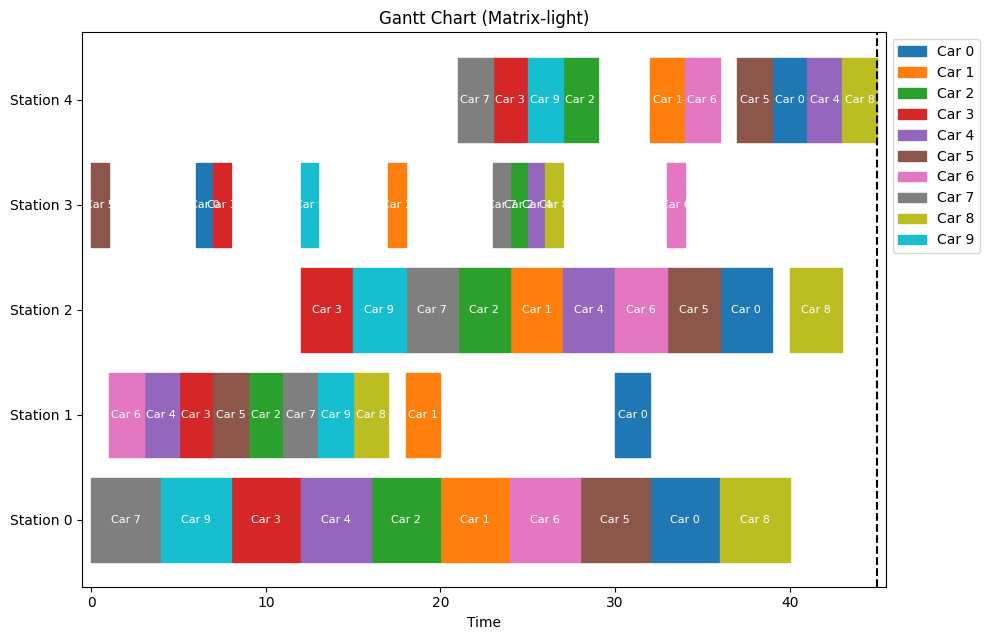

In [32]:
if res["status"] in [GRB.OPTIMAL, GRB.TIME_LIMIT]:
    plot_gantt_matrix_light(V, S, t, res["ST"], res["Cmax"])
else:
    print("No solution.")


In [ ]:
import random
from gurobipy import Model, GRB

def generate_grid_distances(S, rows, cols):
    assert rows * cols == S
    coords = [(r, c) for r in range(rows) for c in range(cols)]
    D = [[0]*S for _ in range(S)]
    for i in range(S):
        for j in range(S):
            (r1,c1) = coords[i]
            (r2,c2) = coords[j]
            D[i][j] = abs(r1-r2) + abs(c1-c2)   # Manhattan distance
    return D

def generate_random_dag_edges(S, p=0.15, seed=1):
    """
    Generates a DAG by only allowing edges (s -> sp) with s < sp.
    p controls density. Ensures acyclic precedence graph.
    """
    rng = random.Random(seed)
    edges = []
    for s in range(S):
        for sp in range(s+1, S):
            if rng.random() < p:
                edges.append((s, sp))
    # Optional: ensure at least a few edges exist
    if len(edges) == 0:
        edges = [(0, S-1)]
    return edges

def solve_matrix_light_single_prec(V, S, t, prec_edges, D=None,
                                  add_car_capacity=True, add_station_capacity=True,
                                 mip_gap=0.05, threads=0, verbose=True):
    cars = range(V)
    stations = range(S)

    if D is None:
        D = [[0 for _ in stations] for __ in stations]

    # processing time accessor: t[s] or t[v][s]
    def p(v, s):
        return t[v][s] if isinstance(t[0], (list, tuple)) else t[s]

    maxD = max(max(row) for row in D) if D else 0
    M = sum(p(v, s) for v in cars for s in stations) + (S - 1) * maxD

    m = Model("matrix_production_light_single_prec")
    m.Params.MIPGap = mip_gap
    if threads != 0:
        m.Params.Threads = threads
    if not verbose:
        m.Params.OutputFlag = 0

    # Variables
    ST = m.addVars(cars, stations, vtype=GRB.CONTINUOUS, lb=0.0, name="ST")
    Cmax = m.addVar(vtype=GRB.CONTINUOUS, lb=0.0, name="Cmax")

    # Station capacity binaries (only v<vp)
    if add_station_capacity:
        UV = m.addVars(
            [(v, vp, s) for s in stations for v in cars for vp in cars if v < vp],
            vtype=GRB.BINARY, name="UV"
        )
    else:
        UV = None

    # Car capacity binaries: only unordered station pairs (s<sp and neither direction in precedence)
    if add_car_capacity:
        edges = set(prec_edges)
        unordered_pairs = [
            (s, sp)
            for s in stations for sp in stations
            if s < sp and (s, sp) not in edges and (sp, s) not in edges
        ]
        SV = m.addVars(
            [(v, s, sp) for v in cars for (s, sp) in unordered_pairs],
            vtype=GRB.BINARY, name="SV"
        )
    else:
        unordered_pairs = []
        SV = None

    # Objective
    m.setObjective(Cmax, GRB.MINIMIZE)

    # (1) Makespan bound
    m.addConstrs((Cmax >= ST[v, s] + p(v, s) for v in cars for s in stations), name="makespan")

    # (2) Precedence constraints (same for all cars)
    for v in cars:
        for (s, sp) in prec_edges:
            m.addConstr(ST[v, sp] >= ST[v, s] + p(v, s) + D[s][sp],
                        name=f"prec_v{v}_{s}_{sp}")

    # (3) Station capacity: no overlap of two cars on same station
    if add_station_capacity:
        for s in stations:
            for v in cars:
                for vp in cars:
                    if v < vp:
                        # UV=1 => v before vp on station s
                        m.addConstr(ST[vp, s] >= ST[v, s] + p(v, s) - M * (1 - UV[v, vp, s]))
                        m.addConstr(ST[v, s]  >= ST[vp, s] + p(vp, s) - M * (UV[v, vp, s]))

    # (4) Car capacity: car cannot be on two stations at once (for unordered pairs)
    if add_car_capacity:
        for v in cars:
            for (s, sp) in unordered_pairs:
                # SV=1 => s before sp
                m.addConstr(ST[v, sp] >= ST[v, s]  + p(v, s)  + D[s][sp]  - M * (1 - SV[v, s, sp]))
                m.addConstr(ST[v, s]  >= ST[v, sp] + p(v, sp) + D[sp][s] - M * (SV[v, s, sp]))

    m.optimize()

    return {
        "status": m.status,
        "Cmax": Cmax.X if m.SolCount > 0 else None,
        "ST": {(v, s): ST[v, s].X for v in cars for s in stations} if m.SolCount > 0 else None,
        "numVars": m.NumVars,
        "numConstrs": m.NumConstrs,
        "MIPGap": m.MIPGap if m.SolCount > 0 else None
    }

# ----------------------------
# Example: 100 cars, 12 stations
# ----------------------------
V = 100
S = 12

seed = 42
random.seed(seed)

# processing times per station (same for all cars) -> keeps model smaller
t = [random.randint(1, 6) for _ in range(S)]

# Layout distances: 3x4 grid
D = generate_grid_distances(S, rows=3, cols=4)

# Precedence DAG: sparse edges, acyclic by construction (s < sp)
prec_edges = generate_random_dag_edges(S, p=0.15, seed=seed)

print("t (per station):", t)
print("Number of precedence edges:", len(prec_edges))
print("Precedence edges:", prec_edges)

# Solve (start with a moderate time limit)
res = solve_matrix_light_single_prec(
    V=V, S=S, t=t, prec_edges=prec_edges, D=D,
    add_car_capacity=True,
    add_station_capacity=True,
    mip_gap=0.05,      # allow 5% gap for speed
    threads=0,
    verbose=True
)

print("\nStatus:", res["status"])
print("Cmax:", res["Cmax"])
print("Vars:", res["numVars"], "Constrs:", res["numConstrs"], "Gap:", res["MIPGap"])


t (per station): [6, 1, 1, 6, 3, 2, 2, 2, 6, 1, 6, 6]
Number of precedence edges: 10
Precedence edges: [(0, 2), (0, 8), (0, 10), (1, 3), (1, 10), (2, 8), (2, 9), (4, 8), (4, 11), (5, 7)]
Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2726523
Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de
Set parameter MIPGap to value 0.05
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: AMD Ryzen 5 7600X 6-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
MIPGap  0.05

Academic license 2726523 - for non-commercial use only - registered to n.___@campus.tu-berlin.de
Optimize a model with 132200 rows, 66201 columns and 394400 nonzeros
Model fingerprint: 0x88c92e55
Variable types: 1201 continuous, 65000 integer (65000 binary)
Coefficient statistics:
  Matrix range     [1

KeyboardInterrupt: 

Exception ignored in: 'gurobipy._core.logcallbackstub'
Traceback (most recent call last):
  File "C:\Users\nicol\AppData\Roaming\Python\Python310\site-packages\ipykernel\iostream.py", line 626, in write
    def write(self, string: str) -> Optional[int]:  # type:ignore[override]
KeyboardInterrupt: 


In [ ]:
import matplotlib.pyplot as plt

def p(t, v, s):
    return t[v][s] if isinstance(t[0], (list, tuple)) else t[s]

def build_tasks(V, S, t, ST_sol):
    tasks = []
    for v in range(V):
        for s in range(S):
            st = ST_sol[(v, s)]
            dur = p(t, v, s)
            tasks.append({"car": v, "station": s, "start": st, "end": st + dur, "dur": dur})
    return tasks

def plot_barcode_gantt(V, S, tasks, Cmax, title="Station schedule (barcode)"):
    fig, ax = plt.subplots(figsize=(12, 0.6*S + 2))
    ax.set_xlim(0, Cmax)
    ax.set_yticks(range(S))
    ax.set_yticklabels([f"Station {s}" for s in range(S)])
    ax.set_xlabel("Time")
    ax.set_title(title)

    # Sort tasks by start for nicer look
    tasks_sorted = sorted(tasks, key=lambda x: (x["station"], x["start"]))

    for task in tasks_sorted:
        s = task["station"]
        ax.broken_barh([(task["start"], task["dur"])], (s - 0.4, 0.8))

    ax.axvline(Cmax, linestyle="--")
    plt.tight_layout()
    plt.show()

def plot_completion_times(V, S, t, ST_sol, title="Completion times of all cars"):
    C_v = []
    for v in range(V):
        cv = max(ST_sol[(v,s)] + p(t, v, s) for s in range(S))
        C_v.append(cv)

    C_sorted = sorted(C_v)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(V), C_sorted, marker=".", linestyle="none")
    ax.set_xlabel("Cars (sorted by completion time)")
    ax.set_ylabel("Completion time")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def plot_station_utilization(V, S, t, tasks, Cmax, title="Station utilization"):
    busy = [0.0]*S
    for task in tasks:
        busy[task["station"]] += task["dur"]

    util = [b / Cmax for b in busy]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(S), util)
    ax.set_xticks(range(S))
    ax.set_xticklabels([f"S{s}" for s in range(S)])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Utilization (busy / Cmax)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


In [ ]:
tasks = build_tasks(V, S, t, res["ST"])
Cmax = res["Cmax"]

plot_barcode_gantt(V, S, tasks, Cmax)
plot_completion_times(V, S, t, res["ST"])
plot_station_utilization(V, S, t, tasks, Cmax)


TypeError: 'NoneType' object is not subscriptable

In [36]:
dddd

NameError: name 'dddd' is not defined

In [ ]:
import gurobipy as gp 
from gurobipy import GRB
from gurobipy import *  # imports everything from gurobipy without alias
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# Model
m = gp.Model("MILP")


# Surpress Output
m.setParam("OutputFlag", 0)
m.setParam("MIPgap", 0)

In [ ]:
Operations = [1,2,3,4,5,6,7,8,9]
#Stations = [1,2,3,4,5,6] 
Stations = [1,2,3,4,5] # changed for task 5+6

N = len(Operations)
M = len(Stations)

PrecRelations = [[1, 2], [3, 4], [3, 7], [1, 5], [3, 5], [5, 6], [1, 8], [2, 8], [3, 8], [4, 8], [5, 8], [6, 8], [7, 8], [8, 9]]
t = [5.2, 2.8, 3, 8.3, 6.7, 3.5, 7, 2, 1] # changed for task 5+6

In [ ]:
S = m.addVars(N, M, vtype=GRB.BINARY, name="S")
C = m.addVar(lb=0, name="C")
symBreak = m.addVar(lb=0, name="symBreak")

In [ ]:
m.setObjective(C + symBreak, GRB.MINIMIZE)

In [ ]:
m.addConstrs((quicksum(S[i, k] for k in range(M)) == 1 for i in range(N)), name="allOperCon");
m.addConstrs((quicksum(S[i, k]*k for k in range(M)) <= quicksum(S[j, k]*k for k in range(M))
              for i in range(N) for j in range(N) if [i+1,j+1] in PrecRelations), name="precRelCon");
m.addConstrs((quicksum(S[i, k]*t[i] for i in range(N)) <= C for k in range(M)), name="cycleTimeCon");
m.addConstr(symBreak >= quicksum(S[i, k]*k*(0.1**(i+1)) for k in range(M) for i in range(N)), name="symBreakCon");

In [ ]:
m
m.optimize()

In [ ]:
# Print results
if m.status == GRB.OPTIMAL:
    print("Objective value: ", m.objVal)
    print("Cycle Time C: ", C.x)
    print("Solution:")
    for i in range(N):

        for k in range(M):
            if S[i, k].x > 0.5:
                print("Operation ", i+1, " is assigned to station ", k+1)
else:
    print("No solution found")